<h2>Exercise 00: Line chart</h2>

In [9]:
import pandas as pd 
import sqlite3

### 1. Make a connection to the database 

In [10]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

### 2. Run a query that gets the datetime from the pageviews table, selecting only users and not admins.

In [11]:
users_views = pd.io.sql.read_sql(
    """
    SELECT
        datetime 
    FROM pageviews
    WHERE uid LIKE 'user_%'
    """,
    conn
)

users_views

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


### 3. Using Pandas, create a new dataframe where the visits are counted and grouped by date.

In [12]:
pd.read_sql('SELECT name FROM sqlite_master WHERE type="table";', conn)


,name
0,pageviews
1,checker
2,deadlines
3,df


In [13]:
count_visit = pd.io.sql.read_sql(
    """
    SELECT
        DATE(datetime) AS date, 
        COUNT(*) as visits
    FROM pageviews
    GROUP BY DATE(datetime)
    ORDER BY date
    """,
    conn
)

count_visit

,date,visits
0,2020-04-17,13
1,2020-04-18,29
2,2020-04-19,20
3,2020-04-20,2
4,2020-04-21,8
5,2020-04-22,8
6,2020-04-23,9
7,2020-04-24,6
8,2020-04-25,1
9,2020-04-26,11


In [14]:
count_visit = count_visit.set_index("date")

### 4. Using the Pandas method .plot(), create a graph.

<Axes: title={'center': 'Views per Day'}, xlabel='date'>

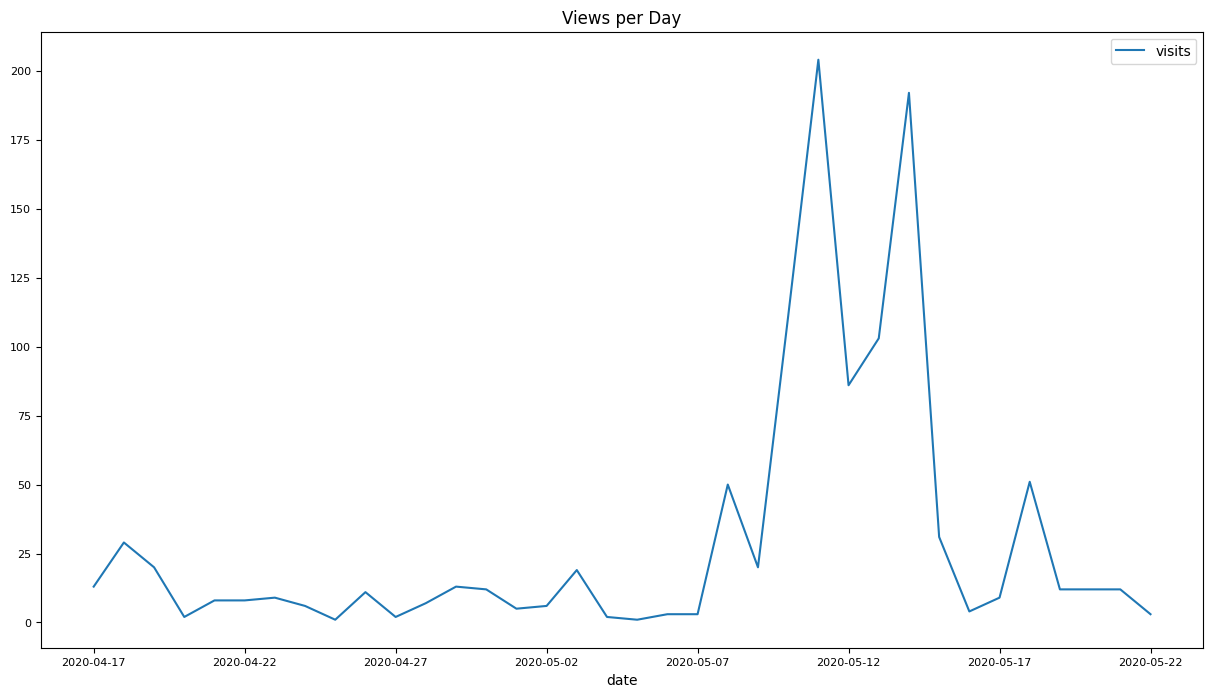

In [15]:
count_visit.plot(
    fontsize=8,
    figsize=(15,8),
    title="Views per Day"

)

### 5. Close the connection to the database.

In [16]:
conn.close()